In [4]:
import os
import sys
import traceback
from pathlib import Path
project_root = Path("/trinity/home/t.samsonov/notebooks/Pirogov/NeuronDeCo")
sys.path.append(str(project_root))

import optuna
from optuna.trial import TrialState
from lib.optuna import (
    feasible_trials_less_zero,
    load_study_sqlite,
    pareto_front,
    plot_trials_fold_curves,
)


In [11]:
db_path = Path("../5-30-no_time_crop_on_train/tfr_s11.db").resolve()

print("cwd:", os.getcwd())
print("db_path:", db_path)
print("exists:", db_path.exists())
print("is_file:", db_path.is_file())
print("parent exists:", db_path.parent.exists())
print("access parent:", os.access(db_path.parent, os.R_OK | os.X_OK))
print("access file:", os.access(db_path, os.R_OK))

cwd: /beegfs/home/t.samsonov/notebooks/Pirogov/MNE_playground/notebooks
db_path: /beegfs/home/t.samsonov/notebooks/Pirogov/MNE_playground/5-30-no_time_crop_on_train/tfr_s11.db
exists: True
is_file: True
parent exists: True
access parent: True
access file: True


In [12]:
db_path = Path("../5-30-no_time_crop_on_train/tfr_s11.db").resolve()

study = load_study_sqlite(db_path=db_path, study_name="tfr_s11")


In [15]:
feasible = feasible_trials_less_zero(study)

print("complete:", sum(t.state == TrialState.COMPLETE for t in study.trials))
print("feasible:", len(feasible))

pareto = pareto_front(feasible, study.directions)
print("Pareto feasible:", len(pareto))

for t in sorted(pareto, key=lambda x: x.values[0], reverse=True)[:10]:
    f1, slope = t.values
    print(f"trial={t.number} f1={f1:.4f} slope={slope:.6f} params={t.params}")

complete: 100
feasible: 36
Pareto feasible: 4
trial=46 f1=0.7775 slope=-0.017437 params={'lr': 0.0009494540587325816, 'weight_decay': 0.00039797493741031153, 'dropout': 0.4913768140803923, 'batch_size': 32}
trial=58 f1=0.7699 slope=-0.081076 params={'lr': 0.0011771291784507558, 'weight_decay': 0.006351221010640704, 'dropout': 0.5123957592679835, 'batch_size': 16}
trial=44 f1=0.7349 slope=-0.410174 params={'lr': 0.0014905943982528463, 'weight_decay': 0.0009184900818511545, 'dropout': 0.48791101869668757, 'batch_size': 16}
trial=38 f1=0.7033 slope=-0.572902 params={'lr': 0.0016207180989873218, 'weight_decay': 0.0003346220103048386, 'dropout': 0.5563679124791538, 'batch_size': 32}


Trial number: 46
Values (f1, slope): [0.7774725274725275, -0.0174372673034668]
Params: {'lr': 0.0009494540587325816, 'weight_decay': 0.00039797493741031153, 'dropout': 0.4913768140803923, 'batch_size': 32}


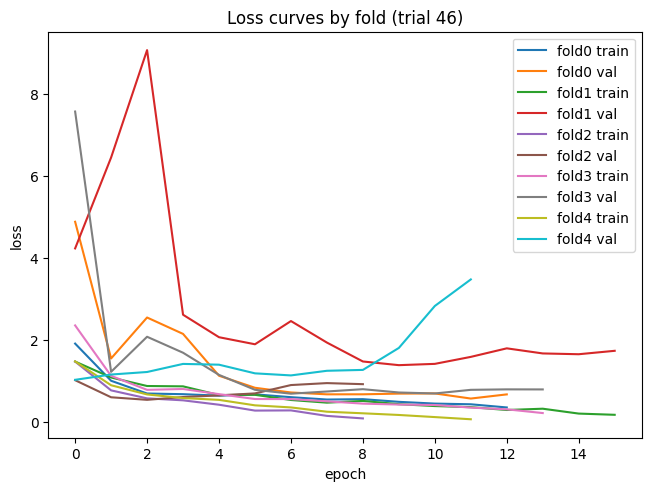

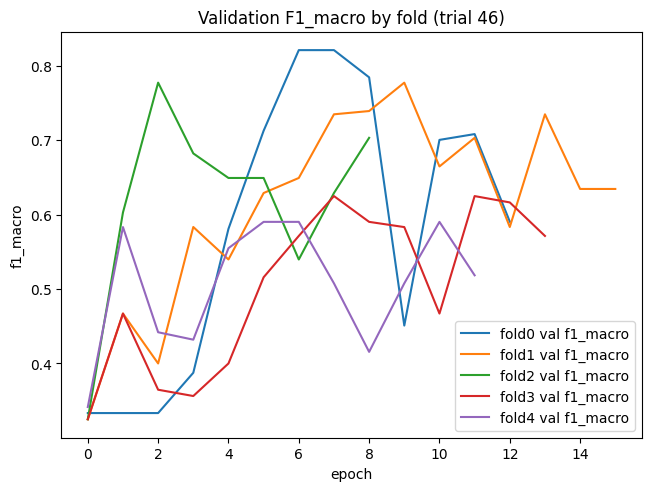

Trial number: 58
Values (f1, slope): [0.7698863636363636, -0.08107575199553194]
Params: {'lr': 0.0011771291784507558, 'weight_decay': 0.006351221010640704, 'dropout': 0.5123957592679835, 'batch_size': 16}


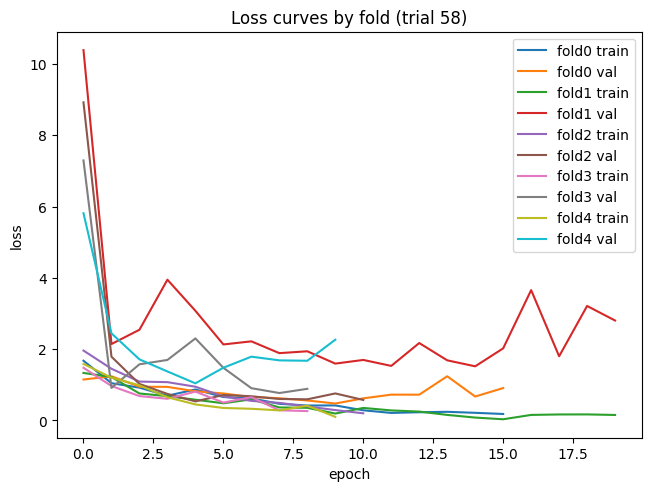

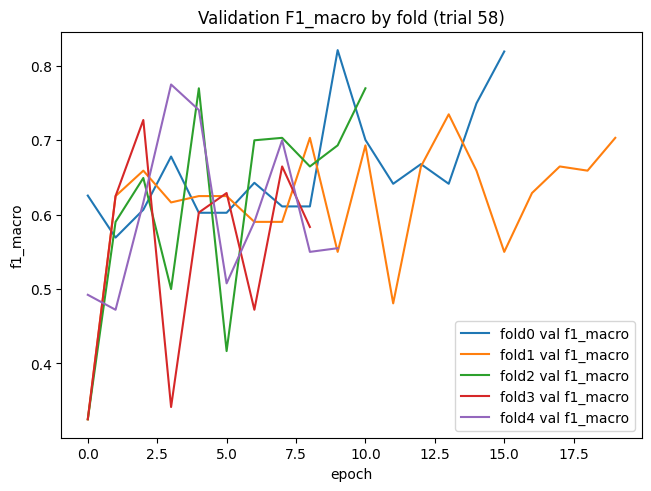

Trial number: 44
Values (f1, slope): [0.7349228611500701, -0.4101739409529129]
Params: {'lr': 0.0014905943982528463, 'weight_decay': 0.0009184900818511545, 'dropout': 0.48791101869668757, 'batch_size': 16}


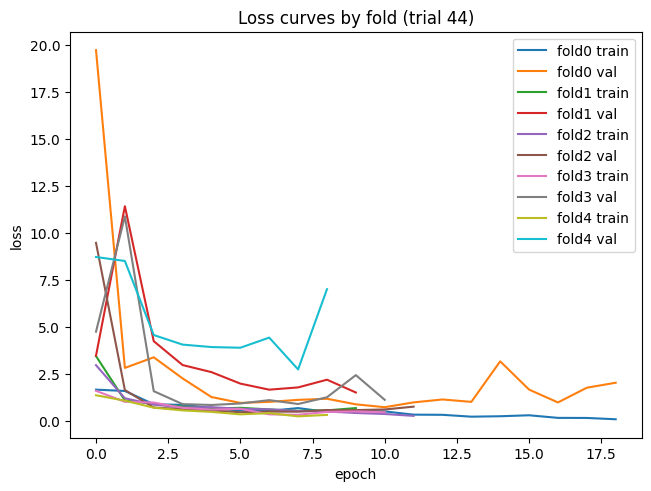

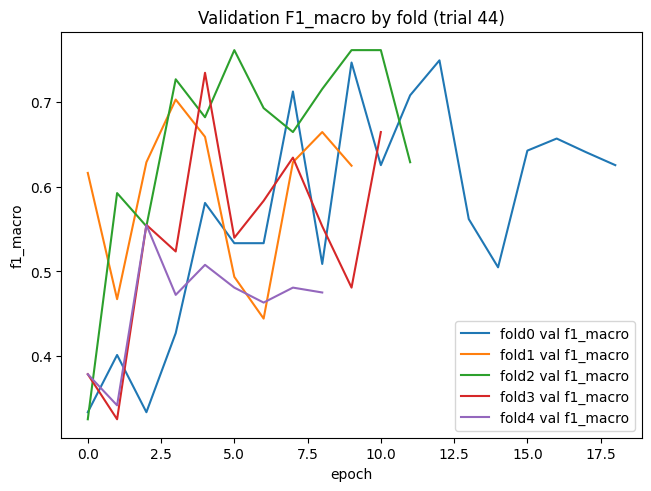

Trial number: 38
Values (f1, slope): [0.7032967032967032, -0.5729016773628468]
Params: {'lr': 0.0016207180989873218, 'weight_decay': 0.0003346220103048386, 'dropout': 0.5563679124791538, 'batch_size': 32}


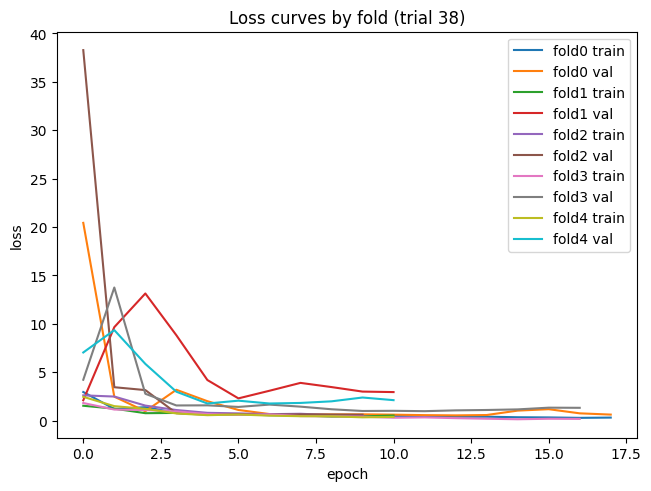

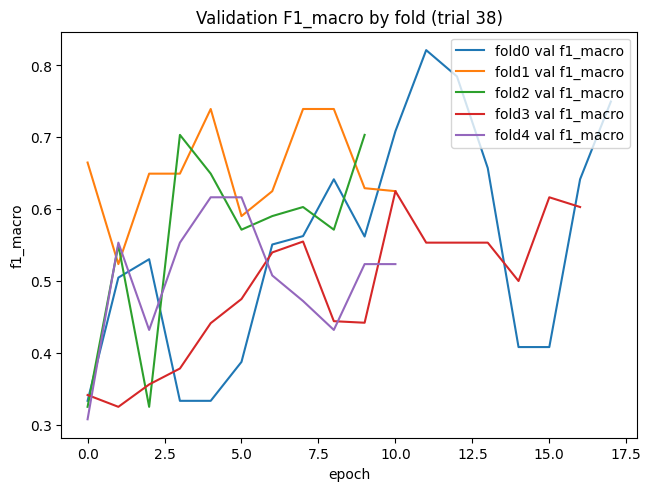

In [16]:
import matplotlib.pyplot as plt

# --- выбери trial по номеру (надёжнее, чем индекс в списке) ---
trial_numbers = [46, 58, 44, 38]
for n in trial_numbers:
    t = next(tr for tr in study.get_trials(deepcopy=False) if tr.number == n)
    # более надёжно, если есть пропуски:
    # t = next(tr for tr in study.get_trials(deepcopy=False) if tr.number == trial_number)

    print("Trial number:", t.number)
    print("Values (f1, slope):", t.values)
    print("Params:", t.params)
    plot_trials_fold_curves(study, [t.number], show=True)
    continue

    # --- новая номенклатура: fold_curves ---
    fold_curves = t.user_attrs.get("fold_curves", None)

    if fold_curves is not None and len(fold_curves) > 0:
        # 1) Loss curves по фолдам
        plt.figure(constrained_layout=True)
        for fc in fold_curves:
            name = fc.get("split", "fold")
            tr_losses = fc.get("train_losses", [])
            va_losses = fc.get("val_losses", [])
            if tr_losses:
                plt.plot(tr_losses, label=f"{name} train")
            if va_losses:
                plt.plot(va_losses, label=f"{name} val")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.title(f"Loss curves by fold (trial {t.number})")
        plt.legend()
        plt.show()

        # 2) F1 curves по фолдам
        plt.figure(constrained_layout=True)
        for fc in fold_curves:
            name = fc.get("split", "fold")
            va_f1s = fc.get("val_f1s", [])
            if va_f1s:
                plt.plot(va_f1s, label=f"{name} val f1_macro")
        plt.xlabel("epoch")
        plt.ylabel("f1_macro")
        plt.title(f"Validation F1_macro by fold (trial {t.number})")
        plt.legend()
        plt.show()

    else:
        # --- fallback: старая номенклатура ---
        train_losses = t.user_attrs.get("train_losses", [])
        val_losses   = t.user_attrs.get("val_losses", [])
        val_f1s      = t.user_attrs.get("val_f1s", [])

        plt.figure(constrained_layout=True)
        if train_losses:
            plt.plot(train_losses, label="train loss")
        if val_losses:
            plt.plot(val_losses, label="val loss")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.title(f"Loss curves (trial {t.number})")
        plt.legend()
        plt.show()

        plt.figure(constrained_layout=True)
        if val_f1s:
            plt.plot(val_f1s, label="val f1_macro")
        plt.xlabel("epoch")
        plt.ylabel("f1_macro")
        plt.title(f"Validation F1_macro (trial {t.number})")
        plt.legend()
        plt.show()

In [ ]:
from optuna.trial import TrialState


def select_trials_top_f1_then_best_losses(
    study,
    *,
    top_f1_n: int = 12,
    top_loss_n: int = 3,
) -> list[int]:
    """
    1) Берем top_f1_n завершенных trial по F1 (по убыванию).
    2) Внутри этого списка выбираем top_loss_n trial с минимальным loss.
    3) Возвращаем выбранные trial в ИСХОДНОМ порядке по F1.

    Пример: после шага 1 получили [4, 5, 2, 1],
    по loss выбрались [1, 5] -> итог вернется как [5, 1].
    """
    complete_trials = [
        t
        for t in study.get_trials(deepcopy=False)
        if t.state == TrialState.COMPLETE and t.values is not None and len(t.values) >= 2
    ]
    if not complete_trials:
        return []

    ranked_by_f1 = sorted(complete_trials, key=lambda t: float(t.values[0]), reverse=True)
    ranked_by_f1 = ranked_by_f1[: max(1, int(top_f1_n))]

    loss_pick_n = min(max(1, int(top_loss_n)), len(ranked_by_f1))

    # Индексы лучших по loss внутри F1-ранжированного списка.
    ranked_indices = list(range(len(ranked_by_f1)))
    best_loss_indices = sorted(
        ranked_indices,
        key=lambda idx: float(ranked_by_f1[idx].values[1]),
    )[:loss_pick_n]

    # Сохраняем порядок по F1.
    keep_idx = set(best_loss_indices)
    selected = [t for i, t in enumerate(ranked_by_f1) if i in keep_idx]

    return [int(t.number) for t in selected]

In [ ]:
from pathlib import Path
from lib.optuna import load_study_sqlite

# Визуализация по конкретному номеру trial
from lib.optuna import plot_trial_fold_curves

study_db = Path("../../PreprocessedData/2026-03-31/tfr_s11_transformer.db")
study_name = "tfr_s11_transformer" # обычно совпадает с именем study в файле

study_s11 = load_study_sqlite(db_path=study_db, study_name=study_name)

selected_trial_numbers = select_trials_top_f1_then_best_losses(
    study_s11,
    top_f1_n=12,   # можно 10..15
    top_loss_n=4,  # можно 3..5
)

print("Selected trial numbers:", selected_trial_numbers)

# Схлопнутый массив в стиле логов:
selected_trials = [
    next(t for t in study_s11.get_trials(deepcopy=False) if t.number == n)
    for n in selected_trial_numbers
]
for t in selected_trials:
    print(
        f"[I] Trial {t.number} values={t.values} params={t.params}"
    )

trial_number = selected_trial_numbers[0] if selected_trial_numbers else 0
print("Visualizing trial:", trial_number)

plot_trial_fold_curves(study_s11, trial_number, show=True)

# Если хотите быстро посмотреть все выбранные:
# from lib.optuna import plot_trials_fold_curves
# plot_trials_fold_curves(study_s11, selected_trial_numbers, show=True)

Selected trial numbers: [0, 34, 9, 27]
[I] Trial 0 values=[0.6415362731152205, 0.7028843462467195] params={'embed_dim': 64, 'preprocess': 'channel_conv', 'batch_size': 32, 'dropout': 0.5010235593143333, 'nhead': 8, 'dim_fc': 512, 'num_layers': 7, 'encoder_dropout': 0.5843058002894633, 'mlp_dropout': 0.26195730291732594, 'use_conv': False, 'conv_kernel_size': 7, 'conv_dropout': 0.17880210041325761, 'pooling': 'mean', 'lr': 0.00022160445973744421, 'weight_decay': 7.987032801740347e-05}
[I] Trial 34 values=[0.6354166666666667, 0.7147398710250855] params={'embed_dim': 128, 'preprocess': 'channel_conv', 'batch_size': 32, 'dropout': 0.4482045260823042, 'nhead': 8, 'dim_fc': 512, 'num_layers': 5, 'encoder_dropout': 0.5543019374652891, 'mlp_dropout': 0.0697190758188547, 'use_conv': False, 'conv_kernel_size': 7, 'conv_dropout': 0.4102179484554278, 'pooling': 'softmax', 'lr': 0.00025093962614071576, 'weight_decay': 4.55667508854731e-06}
[I] Trial 9 values=[0.6164772727272727, 0.6875639379024506]

Visualizing trial: 0


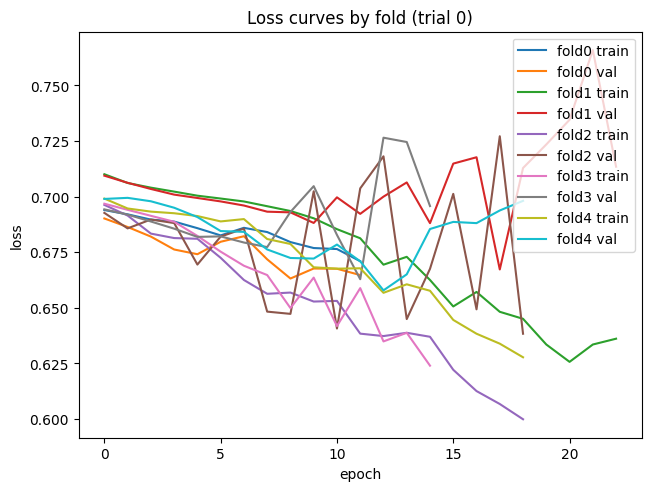

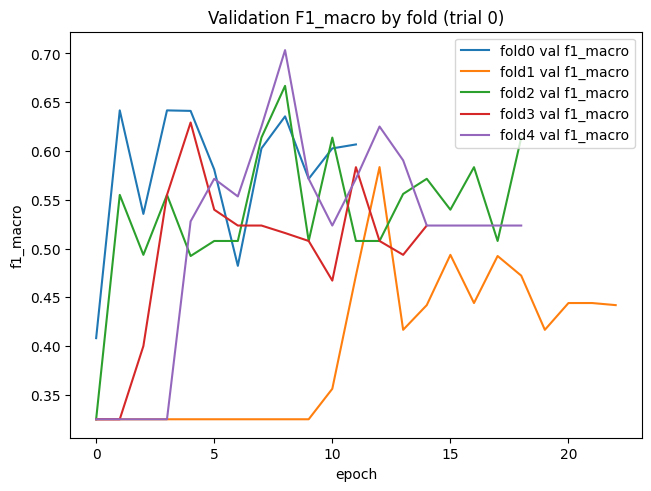

[<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>]

In [19]:
from pathlib import Path
from lib.optuna import load_study_sqlite


study_name = "tfr_s13_alexnet" # обычно совпадает с именем study в файле
study_db = Path(f"../../PreprocessedData/2026-03-31/{study_name}.db")


study_s11 = load_study_sqlite(db_path=study_db, study_name=study_name)

selected_trial_numbers = select_trials_top_f1_then_best_losses(
    study_s11,
    top_f1_n=5,   # можно 10..15
    top_loss_n=2,  # можно 3..5
)

print("Selected trial numbers:", selected_trial_numbers)

# Схлопнутый массив в стиле логов:
selected_trials = [
    next(t for t in study_s11.get_trials(deepcopy=False) if t.number == n)
    for n in selected_trial_numbers
]
for t in selected_trials:
    print(
        f"[I] Trial {t.number} values={t.values} params={t.params}"
    )

Selected trial numbers: [0, 7]
[I] Trial 0 values=[0.7991071428571428, 0.6578345537185668] params={'batch_size': 32, 'dropout': 0.4190609389379256, 'lr': 2.4348773534554605e-05, 'weight_decay': 4.207053950287936e-06}
[I] Trial 7 values=[0.7664071190211346, 0.6628168642520905] params={'batch_size': 32, 'dropout': 0.46376559904778736, 'lr': 5.917607170144197e-05, 'weight_decay': 0.00012030178871154674}


In [ ]:
from pathlib import Path
from lib.optuna import load_study_sqlite


study_name = "tfr_s13_transformer" # обычно совпадает с именем study в файле
study_db = Path(f"../../PreprocessedData/2026-03-31/{study_name}.db")


study_s11 = load_study_sqlite(db_path=study_db, study_name=study_name)

selected_trial_numbers = select_trials_top_f1_then_best_losses(
    study_s11,
    top_f1_n=5,   # можно 10..15
    top_loss_n=2,  # можно 3..5
)

print("Selected trial numbers:", selected_trial_numbers)

# Схлопнутый массив в стиле логов:
selected_trials = [
    next(t for t in study_s11.get_trials(deepcopy=False) if t.number == n)
    for n in selected_trial_numbers
]
for t in selected_trials:
    print(
        f"[I] Trial {t.number} values={t.values} params={t.params}"
    )

Selected trial numbers: [12, 1]
[I] Trial 12 values=[0.7333333333333333, 0.6209739446640015] params={'embed_dim': 256, 'preprocess': 'channel_conv', 'batch_size': 32, 'dropout': 0.18028192073149182, 'nhead': 4, 'dim_fc': 64, 'num_layers': 3, 'encoder_dropout': 0.49762456395200205, 'mlp_dropout': 0.11451947164723783, 'use_conv': False, 'conv_kernel_size': 5, 'conv_dropout': 0.38634429539267184, 'pooling': 'softmax', 'lr': 6.19336666076386e-05, 'weight_decay': 0.005339782591673723}
[I] Trial 1 values=[0.7321428571428572, 0.7025002300739288] params={'embed_dim': 64, 'preprocess': 'pixel_weight', 'batch_size': 32, 'dropout': 0.4143928979410806, 'nhead': 4, 'dim_fc': 64, 'num_layers': 4, 'encoder_dropout': 0.4498433955823936, 'mlp_dropout': 0.26955828724724107, 'use_conv': True, 'conv_kernel_size': 3, 'conv_dropout': 0.11949688597362113, 'pooling': 'mean', 'lr': 0.0004215988942013613, 'weight_decay': 1.579308974316983e-05}


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from optuna.trial import TrialState
from lib.optuna import load_study_sqlite


def select_best_trial_top5_f1_then_min_loss(study):
    """Top-5 by F1, then choose one with minimum loss."""
    complete_trials = [
        t
        for t in study.get_trials(deepcopy=False)
        if t.state == TrialState.COMPLETE and t.values is not None and len(t.values) >= 2
    ]
    if not complete_trials:
        return None

    ranked_by_f1 = sorted(complete_trials, key=lambda t: float(t.values[0]), reverse=True)
    top5 = ranked_by_f1[:5]
    best = min(top5, key=lambda t: float(t.values[1]))
    return best


run_dir = Path("notebooks/Pirogov/PreprocessedData/2026-04-01")
db_paths = sorted(run_dir.glob("tfr_*_*.db"))
if not db_paths:
    raise FileNotFoundError(f"No studies found in: {run_dir}")

study_rows = []
best_rows = []

for db_path in db_paths:
    stem = db_path.stem  # e.g. tfr_s11_transformer
    parts = stem.split("_")
    if len(parts) < 3:
        continue
    patient_id = parts[1]
    method = parts[2]

    study = load_study_sqlite(db_path=db_path, study_name=stem)

    complete_trials = [
        t
        for t in study.get_trials(deepcopy=False)
        if t.state == TrialState.COMPLETE and t.values is not None and len(t.values) >= 2
    ]
    for t in complete_trials:
        study_rows.append(
            {
                "patient": patient_id,
                "method": method,
                "trial_number": int(t.number),
                "f1": float(t.values[0]),
                "loss": float(t.values[1]),
            }
        )

    best_trial = select_best_trial_top5_f1_then_min_loss(study)
    if best_trial is not None:
        best_rows.append(
            {
                "patient": patient_id,
                "method": method,
                "trial_number": int(best_trial.number),
                "f1": float(best_trial.values[0]),
                "loss": float(best_trial.values[1]),
                "params": best_trial.params,
                "db_path": str(db_path),
            }
        )

trials_df = pd.DataFrame(study_rows)
best_df = pd.DataFrame(best_rows).sort_values(["patient", "method"]).reset_index(drop=True)

print(f"Loaded studies: {len(db_paths)}")
print(f"Complete trial rows: {len(trials_df)}")
print("\nBest trial per patient/method (top5 F1 -> min loss):")
display(best_df[["patient", "method", "trial_number", "f1", "loss"]])

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

from lib.optuna import load_study_sqlite


if best_df.empty:
    raise RuntimeError("No best trials. Run previous cell first.")


def _f1_values_for_candlestick(row) -> np.ndarray:
    """
    F1 для «свечи», согласованно с plot_trial_fold_curves (ось X = epoch).

    * Несколько фолдов (K-fold): по одному значению на фолд — F1 на **последней эпохе**
      этого фолда (разброс между фолдами).
    * Один фолд (типичный holdout): все точки **по эпохам** из ``val_f1s`` — иначе
      остаётся одно число и график схлопывается в точку.
    * Нет ``fold_curves``: fallback на плоские ``user_attrs['val_f1s']``.
    """
    db_path = Path(row["db_path"])
    study = load_study_sqlite(db_path=db_path, study_name=db_path.stem)
    trial_num = int(row["trial_number"])
    tr = next(t for t in study.get_trials(deepcopy=False) if int(t.number) == trial_num)
    fold_curves = tr.user_attrs.get("fold_curves", None)

    if not fold_curves:
        flat = tr.user_attrs.get("val_f1s", []) or []
        return np.asarray([float(x) for x in flat], dtype=np.float64)

    if len(fold_curves) > 1:
        out: list[float] = []
        for fc in fold_curves:
            f1s = fc.get("val_f1s", []) or []
            if f1s:
                out.append(float(f1s[-1]))
        return np.asarray(out, dtype=np.float64)

    out = []
    for fc in fold_curves:
        for x in fc.get("val_f1s", []) or []:
            out.append(float(x))
    return np.asarray(out, dtype=np.float64)


method_labels = {
    "alexnet": "AlexNet",
    "transformer": "Transformer",
}
method_colors = {
    "alexnet": (0.0, 0.447, 0.741),      # MATLAB blue
    "transformer": (0.85, 0.325, 0.098), # MATLAB orange
}

lookup = best_df.set_index(["patient", "method"])
patient_order = sorted(best_df["patient"].unique())
methods_order = ["alexnet", "transformer"]

fig, ax = plt.subplots(figsize=(max(12, len(patient_order) * 1.3), 7))

ax.set_axisbelow(True)
ax.grid(which="major", axis="both", linestyle="-", linewidth=0.6, alpha=0.25)
ax.grid(which="minor", axis="both", linestyle="-", linewidth=0.35, alpha=0.12)
ax.minorticks_on()

base_x = np.arange(len(patient_order), dtype=float)
offset = 0.18
box_width = 0.22

all_y = []

for m_idx, method in enumerate(methods_order):
    color = method_colors[method]
    shift = -offset if m_idx == 0 else offset

    for p_idx, patient in enumerate(patient_order):
        key = (patient, method)
        if key not in lookup.index:
            continue
        row = lookup.loc[key]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]

        f1_vals = _f1_values_for_candlestick(row)
        if f1_vals.size == 0:
            continue

        x = base_x[p_idx] + shift
        vmin = float(np.min(f1_vals))
        vmax = float(np.max(f1_vals))
        q1 = float(np.quantile(f1_vals, 0.25))
        q3 = float(np.quantile(f1_vals, 0.75))
        med = float(np.median(f1_vals))
        all_y.extend([vmin, vmax])

        ax.plot([x, x], [vmin, vmax], color=color, linewidth=1.2, alpha=0.95, zorder=2)
        ax.scatter([x, x], [vmin, vmax], color=color, s=22, zorder=3)
        ax.plot([x, x], [q1, q3], color=color, linewidth=7.0, alpha=0.88, zorder=4)
        ax.plot([x - box_width / 2, x + box_width / 2], [med, med], color="black", linewidth=2.2, zorder=5)

ax.set_xticks(base_x)
ax.set_xticklabels(patient_order)
ax.set_xlabel("Patient")
ax.set_ylabel("F1 (val macro)")
ax.set_title(
    "Best trial (top-5 F1 → min loss)\n"
    "K-fold: last-epoch F1 per fold | Holdout: all epoch-wise val F1 (same series as epoch plots)\n"
    "Whisker=min..max of that sample, body=Q1..Q3, black=median"
)

if all_y:
    ymin, ymax = min(all_y), max(all_y)
    pad = max(0.02, 0.08 * (ymax - ymin if ymax > ymin else 1.0))
    ax.set_ylim(ymin - pad, ymax + pad)

legend_handles = [
    Line2D([0], [0], color=method_colors["alexnet"], lw=5, label=method_labels["alexnet"]),
    Line2D([0], [0], color=method_colors["transformer"], lw=5, label=method_labels["transformer"]),
]
ax.legend(handles=legend_handles, loc="best", frameon=True)

plt.tight_layout()
plt.show()